In [2]:
%load_ext autoreload
%autoreload 2

# 0. 导入与数据库连接

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import warnings
warnings.filterwarnings('ignore')
import utils_z

In [4]:
load_dotenv()
conn = utils_z.get_conn(
    os.getenv("DB_NAME"),
    os.getenv("DB_USER"),
    os.getenv("DB_PASSWORD"),
    os.getenv("DB_HOST"),
    os.getenv("DB_PORT")
)
print("数据库连接成功")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

数据库连接成功


# 1. 数据加载与清洗

In [5]:
# ── 所有指标列（25个）──
METRIC_COLS = [
    # Block几何属性
    'area_m2', 'elongation', 'compactness', 'convexity', 'rectangularity',
    # 密度与数量
    'lod1_building_count', 'bcr', 'far', 'bcd', 'osr',
    # 高度
    'avh', 'avh_w', 'hsd', 'hcv', 'h_max', 'h_range',
    # 体量与平面
    'total_volume', 'avg_volume', 'avg_footprint', 'footprint_cv',
    # 建筑形状
    'avg_complexity', 'avg_rectangularity', 'avg_convexity',
    # 分布
    'avg_orientation', 'orientation_entropy', 'avg_nn_distance'
]

query = f"""
    SELECT block_id, city AS _city, {', '.join(METRIC_COLS)}
    FROM block.lod1_valid_blocks
"""
df_raw = pd.read_sql(query, conn)

print(f"原始数据: {df_raw.shape[0]} 行 × {df_raw.shape[1]} 列")

# ── 过滤含NULL的行 ──
df = df_raw[['block_id', '_city'] + METRIC_COLS].dropna(subset=METRIC_COLS)
print(f"过滤NULL后: {df.shape[0]} 行（丢弃 {df_raw.shape[0]-df.shape[0]} 行）")

原始数据: 208344 行 × 28 列
过滤NULL后: 204205 行（丢弃 4139 行）


In [6]:
# ── 异常值截断 ──
# 上截：无界高偏指标
UPPER_CLIP_COLS = [
    'area_m2', 'lod1_building_count', 'far', 'bcd', 'osr',
    'avh', 'avh_w', 'hsd', 'h_max', 'h_range',
    'total_volume', 'avg_volume', 'avg_footprint', 'footprint_cv',
    'avg_complexity', 'avg_nn_distance'
]
# 下截：有异常低值的指标
LOWER_CLIP_COLS = [
    'area_m2', 'avh', 'avh_w', 'h_max',
    'avg_footprint', 'avg_nn_distance'
]

upper_bounds = df[UPPER_CLIP_COLS].quantile(0.99)
lower_bounds = df[LOWER_CLIP_COLS].quantile(0.01)

mask = pd.Series(True, index=df.index)
for col in UPPER_CLIP_COLS:
    mask &= df[col] <= upper_bounds[col]
for col in LOWER_CLIP_COLS:
    mask &= df[col] >= lower_bounds[col]

df_clean = df[mask].copy()

n_raw   = len(df)
n_clean = len(df_clean)
print(f"原始行数:   {n_raw:,}")
print(f"截断后行数: {n_clean:,}")
print(f"删除行数:   {n_raw - n_clean:,}  ({(n_raw - n_clean)/n_raw*100:.1f}%)")

原始行数:   204,205
截断后行数: 181,858
删除行数:   22,347  (10.9%)


# 2. Z-score 标准化

In [7]:
# ── 19个保留指标（硬编码常量）──
CLUSTER_COLS = [
    'area_m2', 'elongation', 'compactness', 'convexity', 'rectangularity',
    'lod1_building_count', 'bcr', 'far',
    'avg_nn_distance',
    'avh', 'hcv',
    'total_volume', 'avg_footprint', 'footprint_cv',
    'avg_complexity', 'avg_rectangularity', 'avg_convexity',
    'avg_orientation', 'orientation_entropy'
]

print(f"保留指标数: {len(CLUSTER_COLS)}")
print(f"指标列表: {CLUSTER_COLS}")

保留指标数: 19
指标列表: ['area_m2', 'elongation', 'compactness', 'convexity', 'rectangularity', 'lod1_building_count', 'bcr', 'far', 'avg_nn_distance', 'avh', 'hcv', 'total_volume', 'avg_footprint', 'footprint_cv', 'avg_complexity', 'avg_rectangularity', 'avg_convexity', 'avg_orientation', 'orientation_entropy']


In [8]:
# ── 提取矩阵并标准化 ──
X = df_clean[CLUSTER_COLS].values          # 原始值
block_ids = df_clean['block_id']           # 对应的block_id

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"X shape:         {X.shape}")
print(f"X_scaled shape:  {X_scaled.shape}")
print(f"block_ids count: {len(block_ids)}")

X shape:         (181858, 19)
X_scaled shape:  (181858, 19)
block_ids count: 181858


In [9]:
# ── 验证标准化结果：均值≈0，标准差≈1 ──
print("标准化验证：")
print(f"{'指标':<22} {'均值':>8} {'标准差':>8}")
print("-" * 40)
for i, col in enumerate(CLUSTER_COLS):
    mean_val = X_scaled[:, i].mean()
    std_val  = X_scaled[:, i].std()
    print(f"{col:<22} {mean_val:>8.4f} {std_val:>8.4f}")

标准化验证：
指标                           均值      标准差
----------------------------------------
area_m2                  0.0000   1.0000
elongation              -0.0000   1.0000
compactness             -0.0000   1.0000
convexity                0.0000   1.0000
rectangularity          -0.0000   1.0000
lod1_building_count      0.0000   1.0000
bcr                     -0.0000   1.0000
far                      0.0000   1.0000
avg_nn_distance          0.0000   1.0000
avh                      0.0000   1.0000
hcv                      0.0000   1.0000
total_volume            -0.0000   1.0000
avg_footprint            0.0000   1.0000
footprint_cv             0.0000   1.0000
avg_complexity           0.0000   1.0000
avg_rectangularity      -0.0000   1.0000
avg_convexity           -0.0000   1.0000
avg_orientation         -0.0000   1.0000
orientation_entropy      0.0000   1.0000


# 3. DBSCAN 测试
## 3.1 参数选择（k-distance 图 确定eps和sample）

In [10]:
# ── k-distance 计算函数 ──
SAMPLE_SIZE = 50_000

def compute_kdistances(X_data, ks, sample_size=None):
    """
    计算多个k值的k-distance。
    
    Parameters
    ----------
    X_data : np.ndarray
        标准化后的特征矩阵
    ks : list[int]
        k值列表，对应DBSCAN的min_samples
    sample_size : int or None
        采样数，大于此值时随机采样以加速
    
    Returns
    -------
    dict[int, np.ndarray]
        {k: 排序后的第k近邻距离数组}
    """
    if sample_size and len(X_data) > sample_size:
        rng = np.random.RandomState(42)
        idx = rng.choice(len(X_data), sample_size, replace=False)
        X_use = X_data[idx]
        print(f"采样 {sample_size} 点（共 {len(X_data)}）")
    else:
        X_use = X_data
        print(f"使用全部 {len(X_use)} 点")

    result = {}
    for k in ks:
        nn = NearestNeighbors(n_neighbors=k, metric='euclidean', n_jobs=-1)
        nn.fit(X_use)
        distances, _ = nn.kneighbors(X_use)
        k_dist = np.sort(distances[:, -1])  # 第k近邻距离，升序排列
        result[k] = k_dist
        print(f"  k={k} 计算完成")

    return result

使用全部 181858 点
  k=5 计算完成
  k=10 计算完成
  k=20 计算完成
  k=30 计算完成
k= 5:  p90=2.235  p95=2.624  p99=3.513
k=10:  p90=2.427  p95=2.852  p99=3.805
k=20:  p90=2.621  p95=3.080  p99=4.122
k=30:  p90=2.737  p95=3.220  p99=4.316


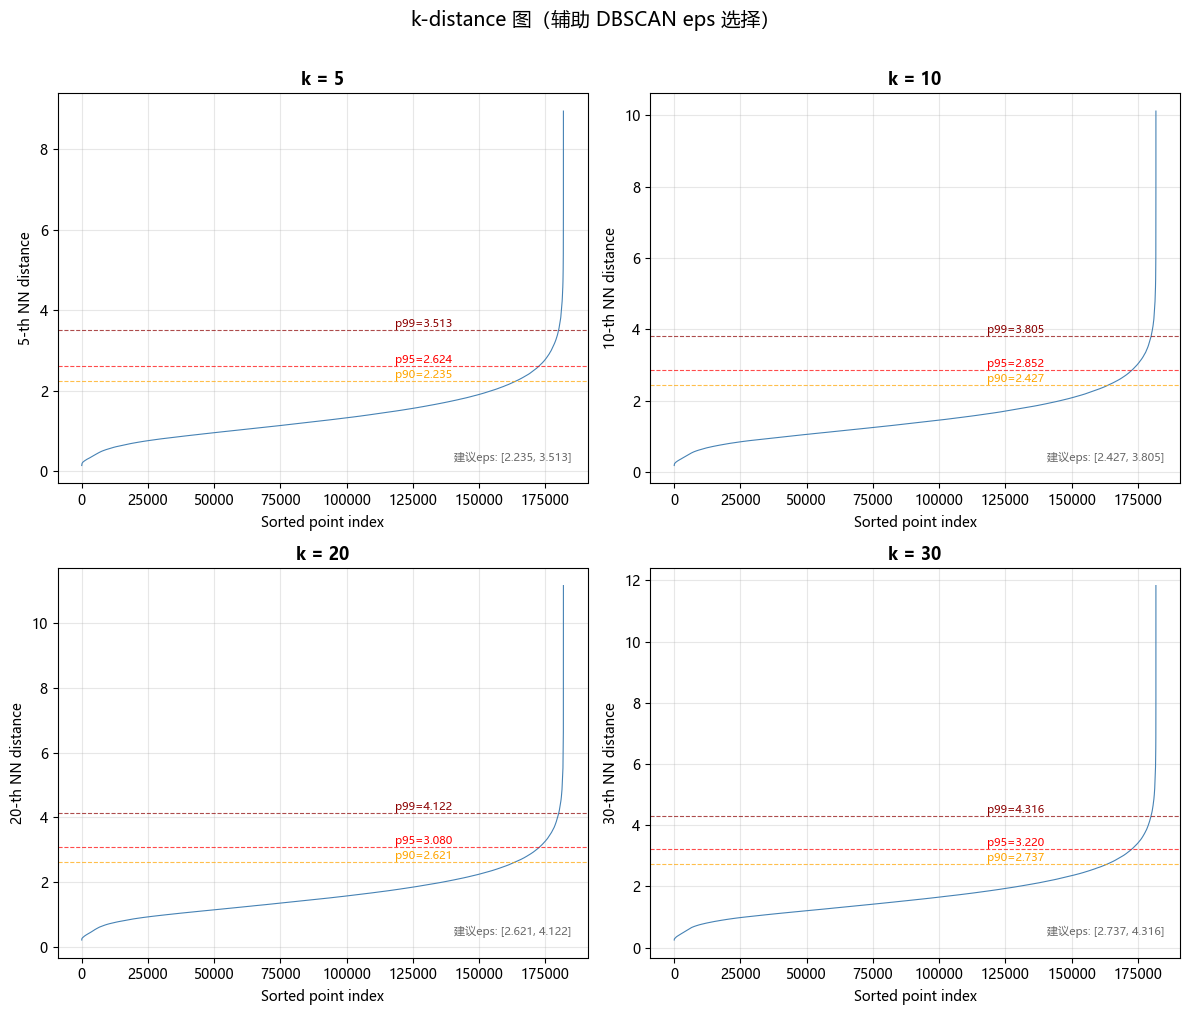

In [11]:
ks = [5, 10, 20, 30]

# ── 计算k-distance ──
kdist_dict = compute_kdistances(X_scaled, ks)
# kdist_dict = compute_kdistances(X_scaled, ks, sample_size=SAMPLE_SIZE)

# ── 绘制四子图 ──
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (k, k_dist) in enumerate(kdist_dict.items()):
    ax = axes[idx]
    ax.plot(range(len(k_dist)), k_dist, linewidth=0.8, color='steelblue')
    ax.set_title(f'k = {k}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Sorted point index')
    ax.set_ylabel(f'{k}-th NN distance')
    ax.grid(True, alpha=0.3)

    # 百分位值
    p90 = np.percentile(k_dist, 90)
    p95 = np.percentile(k_dist, 95)
    p99 = np.percentile(k_dist, 99)

    # 标注水平参考线
    ax.axhline(p90, color='orange', linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axhline(p95, color='red',    linestyle='--', linewidth=0.8, alpha=0.7)
    ax.axhline(p99, color='darkred',linestyle='--', linewidth=0.8, alpha=0.7)

    ax.text(len(k_dist) * 0.65, p90, f'p90={p90:.3f}', fontsize=8, color='orange', va='bottom')
    ax.text(len(k_dist) * 0.65, p95, f'p95={p95:.3f}', fontsize=8, color='red',    va='bottom')
    ax.text(len(k_dist) * 0.65, p99, f'p99={p99:.3f}', fontsize=8, color='darkred',va='bottom')

    # 建议eps区间（基于p90~p99范围）
    eps_low  = f"{p90:.3f}"
    eps_high = f"{p99:.3f}"
    ax.text(0.97, 0.05, f'建议eps: [{eps_low}, {eps_high}]',
            transform=ax.transAxes, ha='right', va='bottom',
            fontsize=8, color='dimgray', fontstyle='italic')

    # 控制台打印百分位值
    print(f"k={k:2d}:  p90={p90:.3f}  p95={p95:.3f}  p99={p99:.3f}")

plt.suptitle('k-distance 图（辅助 DBSCAN eps 选择）', fontsize=14, y=1.01)
plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/02_kdistance.png', dpi=300, bbox_inches='tight')
# plt.show()

## 3.2 DBSCAN 参数网格扫描

根据k-distance图输出，在肘点附近取候选eps值 × min_samples值构成参数网格，逐个跑DBSCAN，用**总览表**辅助选择最佳参数组合。

> ⚠️ Silhouette Score 对非噪声点采样计算（默认 15,000 点），避免O(n²)开销。
> 默认eps候选值基于常见范围设定，运行后请根据k-distance输出调整。

In [12]:
# ═══════════════════════════════════════════════════════════
#  候选参数定义
#  eps: 根据 Step 2 k-distance 图的肘点附近范围手动设定
#        参考 k=10（或 k=20）的 p90~p99 区间
#  min_samples: 与 k 值对应
# ═══════════════════════════════════════════════════════════

# ── TODO: 根据上方 k-distance 输出调整以下 eps 候选值 ──
#   例如 k=10 的 p95≈1.8, p99≈2.6 → eps ≈ [1.2, 1.6, 2.0, 2.4, 2.8]
EPS_VALUES = [1.5, 2.0, 2.5, 3.0, 3.5]
MIN_SAMPLES_VALUES = [5, 10, 20, 30]
SCAN_SAMPLE         = 50_000

# silhouette 采样数（非噪声点中随机采）
SILHOUETTE_SAMPLE = 15_000

print(f"eps 候选值:        {EPS_VALUES}")
print(f"min_samples 候选值: {MIN_SAMPLES_VALUES}")
print(f"参数组合数:         {len(EPS_VALUES) * len(MIN_SAMPLES_VALUES)}")

eps 候选值:        [1.5, 2.0, 2.5, 3.0, 3.5]
min_samples 候选值: [5, 10, 20, 30]
参数组合数:         20


In [13]:
def dbscan_grid_search(X, eps_values, min_samples_values, sil_sample=15_000, scan_sample=None):
    """
    DBSCAN 参数网格搜索（扫描阶段可采样避免内存堆积）。
    
    对每个 (eps, min_samples) 组合：
      1. 如果 scan_sample 有值且数据超过它，先采样再跑 DBSCAN
      2. 计算：聚类数（排除噪声）、噪声比例、Silhouette Score
    
    Silhouette 从非噪声点中随机采样 sil_sample 个点计算。
    每轮结束后 del db / labels 主动释放内存。
    
    Parameters
    ----------
    scan_sample : int or None
        扫描阶段采样数。全量超过此值时采样加速并避免内存膨胀。
    
    Returns
    -------
    pd.DataFrame
        列: eps, min_samples, n_clusters, noise_pct, sil_score, n_noise
    """
    # ── 采样（如果启用）──
    if scan_sample and len(X) > scan_sample:
        rng = np.random.RandomState(42)
        idx = rng.choice(len(X), scan_sample, replace=False)
        X_use = X[idx]
        print(f"🔸 扫描采样 {scan_sample:,} 点（全量 {len(X):,}），每轮聚类后释放内存\n")
    else:
        X_use = X
        print(f"🔸 使用全部 {len(X_use):,} 点\n")

    records = []
    total = len(eps_values) * len(min_samples_values)

    for i, eps in enumerate(eps_values):
        for j, min_samples in enumerate(min_samples_values):
            idx = i * len(min_samples_values) + j + 1

            # ── 跑 DBSCAN ──
            print(f"  [{idx}/{total}] eps={eps:.2f}, min_samples={min_samples}  → 正在聚类...", end=' ')
            db = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
            labels = db.fit_predict(X_use)

            n_total    = len(labels)
            noise_mask = labels == -1
            n_noise    = noise_mask.sum()
            noise_pct  = n_noise / n_total * 100

            core_mask = ~noise_mask
            n_clusters = len(set(labels[core_mask]))

            # ── Silhouette Score（采样非噪声点）──
            if n_clusters >= 2 and core_mask.sum() > sil_sample:
                rng_sil = np.random.RandomState(42)
                idx_core = np.where(core_mask)[0]
                sampled = rng_sil.choice(idx_core, sil_sample, replace=False)
                sil = silhouette_score(X_use[sampled], labels[sampled], metric='euclidean', random_state=42)
            elif n_clusters >= 2:
                sil = silhouette_score(X_use[core_mask], labels[core_mask], metric='euclidean', random_state=42)
            else:
                sil = np.nan

            print(f"n_clusters={n_clusters}, noise={noise_pct:.1f}%, sil={sil:.4f}")

            records.append({
                'eps':          eps,
                'min_samples':  min_samples,
                'n_clusters':   n_clusters,
                'noise_pct':    round(noise_pct, 1),
                'sil_score':    round(sil, 4),
                'n_noise':      n_noise
            })

            # ── 主动释放 DBSCAN 内部 ball_tree 引用 ──
            del db
            del labels

    return pd.DataFrame(records)

In [ ]:
print("=" * 60)
print("DBSCAN 参数网格扫描开始")
print(f"数据集: {X_scaled.shape[0]} 点 × {X_scaled.shape[1]} 维")
print("=" * 60)

df_grid = dbscan_grid_search(
    X_scaled,
    eps_values=EPS_VALUES,
    min_samples_values=MIN_SAMPLES_VALUES,
    sil_sample=SILHOUETTE_SAMPLE,
    scan_sample=SCAN_SAMPLE
)

print("\n" + "=" * 60)
print("参数扫描总览")
print("=" * 60)
print(f"{'eps':>5}  {'min_s':>6}  {'n_clusters':>10}  {'noise%':>7}  {'silhouette':>10}  {'n_noise':>8}")
print("-" * 52)
for _, row in df_grid.iterrows():
    print(f"{row['eps']:>5.2f}  {int(row['min_samples']):>6d}  {int(row['n_clusters']):>10d}  {row['noise_pct']:>6.1f}%  {row['sil_score']:>10.4f}  {int(row['n_noise']):>8d}")

# ── 标记候选组合：n_clusters 5~20, noise < 15%, silhouette 最高 ──
candidates = df_grid[
    (df_grid['n_clusters'] >= 5) &
    (df_grid['n_clusters'] <= 20) &
    (df_grid['noise_pct'] < 15.0)
].copy()

if len(candidates) > 0:
    best = candidates.loc[candidates['sil_score'].idxmax()]
    print(f"\n🔷 推荐组合（候选中最优）:")
    print(f"   eps={best['eps']:.2f}, min_samples={int(best['min_samples'])}, "
          f"n_clusters={int(best['n_clusters'])}, noise={best['noise_pct']:.1f}%, "
          f"silhouette={best['sil_score']:.4f}")
    print(f"\n👉 如果推荐组合不理想，请手动从上面总览表中选择合适的参数，"
          f"填入 Cell 5.1 的 SELECTED_EPS 和 SELECTED_MIN_SAMPLES 中。")
else:
    print("\n⚠️ 无组合同时满足 n_clusters 5~20 且 noise < 15%，请扩大 eps 范围后重试。")

DBSCAN 参数网格扫描开始
数据集: 181858 点 × 19 维
🔸 扫描采样 50,000 点（全量 181,858），每轮聚类后释放内存

  [1/20] eps=1.50, min_samples=5  → 正在聚类... n_clusters=46, noise=37.5%, sil=-0.1673
  [2/20] eps=1.50, min_samples=10  → 正在聚类... n_clusters=14, noise=42.3%, sil=0.0257
  [3/20] eps=1.50, min_samples=20  → 正在聚类... n_clusters=4, noise=47.4%, sil=0.3722
  [4/20] eps=1.50, min_samples=30  → 正在聚类... n_clusters=2, noise=50.0%, sil=0.4711
  [5/20] eps=2.00, min_samples=5  → 正在聚类... n_clusters=26, noise=16.7%, sil=-0.0193
  [6/20] eps=2.00, min_samples=10  → 正在聚类... n_clusters=6, noise=19.4%, sil=0.1689
  [7/20] eps=2.00, min_samples=20  → 正在聚类... n_clusters=2, noise=22.6%, sil=0.4063
  [8/20] eps=2.00, min_samples=30  → 正在聚类... n_clusters=2, noise=24.5%, sil=0.4092
  [9/20] eps=2.50, min_samples=5  → 正在聚类... n_clusters=9, noise=6.9%, sil=0.2721
  [10/20] eps=2.50, min_samples=10  → 正在聚类... n_clusters=6, noise=8.3%, sil=0.3116
  [11/20] eps=2.50, min_samples=20  → 正在聚类... n_clusters=2, noise=10.1%, sil=0.3730
  [12/20]

ValueError: Unknown format code 'd' for object of type 'float'

## 3.3 选定参数 — 详细输出

从总览表中选定最优 (eps, min_samples) 组合后，全量跑一次 DBSCAN，输出：
- 各 cluster 的 block 数量与占比
- 各 cluster 的 19 个指标均值（用于形态解读）
- 噪声点特征分析

In [16]:
# ═══════════════════════════════════════════════════════════
#  选定最终参数（从上方总览表中选择后填入）
# ═══════════════════════════════════════════════════════════

# ── 根据 df_grid 总览表的分析结果，手动填入──
SELECTED_EPS         = 2.5   # ← 推荐: eps=2.5, min_samples=10（6个cluster, noise=8.3%, sil=0.31）
SELECTED_MIN_SAMPLES = 10    # ← 替换为实际选定的 min_samples

print(f"最终参数: eps={SELECTED_EPS}, min_samples={SELECTED_MIN_SAMPLES}")
print("正在全量运行 DBSCAN...")

db_final = DBSCAN(eps=SELECTED_EPS, min_samples=SELECTED_MIN_SAMPLES, n_jobs=-1)
labels   = db_final.fit_predict(X_scaled)

noise_mask = labels == -1
n_total    = len(labels)
n_noise    = noise_mask.sum()
noise_pct  = n_noise / n_total * 100
n_clusters = len(set(labels[~noise_mask]))

print(f"\n聚类完成:")
print(f"  总 block 数:   {n_total:,}")
print(f"  聚类数:        {n_clusters}")
print(f"  噪声点数:      {n_noise:,}  ({noise_pct:.1f}%)")

# ── 保存为模块级变量，供后续分析使用 ──
FINAL_LABELS  = labels
FINAL_EPS     = SELECTED_EPS
FINAL_MIN_SAM = SELECTED_MIN_SAMPLES

最终参数: eps=2.5, min_samples=10
正在全量运行 DBSCAN...

聚类完成:
  总 block 数:   181,858
  聚类数:        5
  噪声点数:      8,939  (4.9%)


In [17]:
# ═══════════════════════════════════════════════════════════
#  各 Cluster 的 Block 数量与占比
# ═══════════════════════════════════════════════════════════

unique_labels = sorted([l for l in set(labels) if l >= 0])

print(f"{'Cluster':>8}  {'Block数':>10}  {'占比':>8}  {'累计占比':>8}")
print("-" * 40)

total_non_noise = n_total - n_noise
cum_pct = 0.0

cluster_sizes = []
for label in unique_labels:
    count = (labels == label).sum()
    pct   = count / total_non_noise * 100
    cum_pct += pct
    cluster_sizes.append((label, count, pct))
    print(f"  {int(label):>6d}  {count:>10,d}  {pct:>7.2f}%  {cum_pct:>7.2f}%")

if n_noise > 0:
    print(f"  {'噪声':>6}  {n_noise:>10,d}  {n_noise/n_total*100:>7.2f}%  {'-':>8}")

print(f"\n总计: {n_total:,} blocks（含 {n_noise:,} 噪声）")

 Cluster      Block数        占比      累计占比
----------------------------------------
       0     172,893    99.98%    99.98%
       1           4     0.00%    99.99%
       2           7     0.00%    99.99%
       3           9     0.01%   100.00%
       4           6     0.00%   100.00%
      噪声       8,939     4.92%         -

总计: 181,858 blocks（含 8,939 噪声）


In [18]:
# ═══════════════════════════════════════════════════════════
#  Cluster 画像：19 个保留指标的均值
# ═══════════════════════════════════════════════════════════

# 将 labels 赋值到 df_clean 中，方便计算
df_clean = df_clean.copy()
df_clean['cluster'] = labels

# 按 cluster 分组算均值（只保留 19 个聚类指标）
cluster_means = df_clean[df_clean['cluster'] >= 0].groupby('cluster')[CLUSTER_COLS].mean()

# 加一列块数
cluster_counts = df_clean[df_clean['cluster'] >= 0].groupby('cluster').size()
cluster_means.insert(0, 'n_blocks', cluster_counts)

print("各 Cluster 的 19 个指标均值（用于形态解读）：")
print(f"\n{'Cluster':>8}  {'n_blocks':>10}", end='')
for col in CLUSTER_COLS:
    print(f"  {col:>18}", end='')
print()
print("-" * (10 + 12 + 20 * len(CLUSTER_COLS)))

for label in sorted(cluster_means.index):
    row = cluster_means.loc[label]
    print(f"  {label:>6d}  {int(row['n_blocks']):>10,d}", end='')
    for col in CLUSTER_COLS:
        print(f"  {row[col]:>16.4f}", end='')
    print()

# ── 可选：全局均值作为参照 ──
print("\n--- 全局均值（参照）---")
global_means = df_clean[CLUSTER_COLS].mean()
print(f"{'全局':>8}  {'-':>10}", end='')
for col in CLUSTER_COLS:
    print(f"  {global_means[col]:>16.4f}", end='')
print()

各 Cluster 的 19 个指标均值（用于形态解读）：

 Cluster    n_blocks             area_m2          elongation         compactness           convexity      rectangularity  lod1_building_count                 bcr                 far     avg_nn_distance                 avh                 hcv        total_volume       avg_footprint        footprint_cv      avg_complexity  avg_rectangularity       avg_convexity     avg_orientation  orientation_entropy
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       0     172,893        11627.9361            2.5724            0.6731            0.9730            0.8373           30.4921            0.3352            1.103

In [ ]:
# ═══════════════════════════════════════════════════════════
#  噪声点特征分析
#  比较噪声点 vs 非噪声点的指标均值偏差
# ═══════════════════════════════════════════════════════════

noise_data   = df_clean[df_clean['cluster'] == -1]
core_data    = df_clean[df_clean['cluster'] >= 0]

n_noise = len(noise_data)
n_core  = len(core_data)

noise_means  = noise_data[CLUSTER_COLS].mean()
core_means   = core_data[CLUSTER_COLS].mean()

# Z-score 偏差（相对于非噪声点的均值和标准差）
core_std = core_data[CLUSTER_COLS].std()
z_deviation = (noise_means - core_means) / core_std

print(f"噪声点数量: {n_noise:,}  ({n_noise/len(df_clean)*100:.1f}%)")
print(f"非噪声点:   {n_core:,}")
print()
print(f"{'指标':<22} {'噪声均值':>10} {'非噪声均值':>10} {'Z偏差':>8} {'偏离方向':>8}")
print("-" * 62)

for col in CLUSTER_COLS:
    noise_mean = noise_means[col]
    core_mean  = core_means[col]
    z = z_deviation[col]

    if abs(z) >= 1.0:
        direction = '⬆偏大' if z > 0 else '⬇偏小'
    else:
        direction = '≈相近'

    print(f"{col:<22} {noise_mean:>10.3f} {core_mean:>10.3f} {z:>+7.2f}  {direction:>8}")

print("\n说明：Z偏差 = (噪声均值 - 非噪声均值) / 非噪声标准差")
print("|Z| ≥ 1.0 表示噪声在该指标上有明显偏离，是噪声的主要特征。")

# 4. K-Means 测试

## 4.1 K 值扫描（Elbow + Silhouette 曲线）

In [28]:
# ═══════════════════════════════════════════════════════════
#  K 值扫描：K=5→20，记录 inertia + silhouette
#  Silhouette 采样 15,000 点避免 O(n²) 开销
# ═══════════════════════════════════════════════════════════

K_RANGE = range(5, 21)
SILHOUETTE_SAMPLE = 15_000

inertia_list  = []
sil_list      = []
k_values      = []

total_km = len(K_RANGE)

for idx, k in enumerate(K_RANGE, 1):
    print(f"  [{idx}/{total_km}] K={k}  → 正在聚类...", end=' ')

    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km_labels = km.fit_predict(X_scaled)

    inertia_list.append(km.inertia_)
    k_values.append(k)

    # ── Silhouette（采样）──
    if k >= 2 and len(X_scaled) > SILHOUETTE_SAMPLE:
        rng = np.random.RandomState(42)
        idx_sil = rng.choice(len(X_scaled), SILHOUETTE_SAMPLE, replace=False)
        sil = silhouette_score(X_scaled[idx_sil], km_labels[idx_sil], metric='euclidean', random_state=42)
    elif k >= 2:
        sil = silhouette_score(X_scaled, km_labels, metric='euclidean', random_state=42)
    else:
        sil = np.nan

    sil_list.append(sil)
    print(f"inertia={km.inertia_:.0f}, sil={sil:.4f}")

    # 释放内存
    del km, km_labels

print("\n扫描完成")

  [1/16] K=5  → 正在聚类... inertia=2359830, sil=0.1866
  [2/16] K=6  → 正在聚类... inertia=2227053, sil=0.1112
  [3/16] K=7  → 正在聚类... inertia=2119379, sil=0.1148
  [4/16] K=8  → 正在聚类... inertia=2029085, sil=0.1182
  [5/16] K=9  → 正在聚类... inertia=1949175, sil=0.1162
  [6/16] K=10  → 正在聚类... inertia=1872345, sil=0.1203
  [7/16] K=11  → 正在聚类... inertia=1817901, sil=0.1147
  [8/16] K=12  → 正在聚类... inertia=1772038, sil=0.1159
  [9/16] K=13  → 正在聚类... inertia=1730789, sil=0.1099
  [10/16] K=14  → 正在聚类... inertia=1694282, sil=0.1125
  [11/16] K=15  → 正在聚类... inertia=1661523, sil=0.1068
  [12/16] K=16  → 正在聚类... inertia=1630479, sil=0.1078
  [13/16] K=17  → 正在聚类... inertia=1601261, sil=0.1084
  [14/16] K=18  → 正在聚类... inertia=1575478, sil=0.1100
  [15/16] K=19  → 正在聚类... inertia=1555604, sil=0.1095
  [16/16] K=20  → 正在聚类... inertia=1534527, sil=0.1108

扫描完成


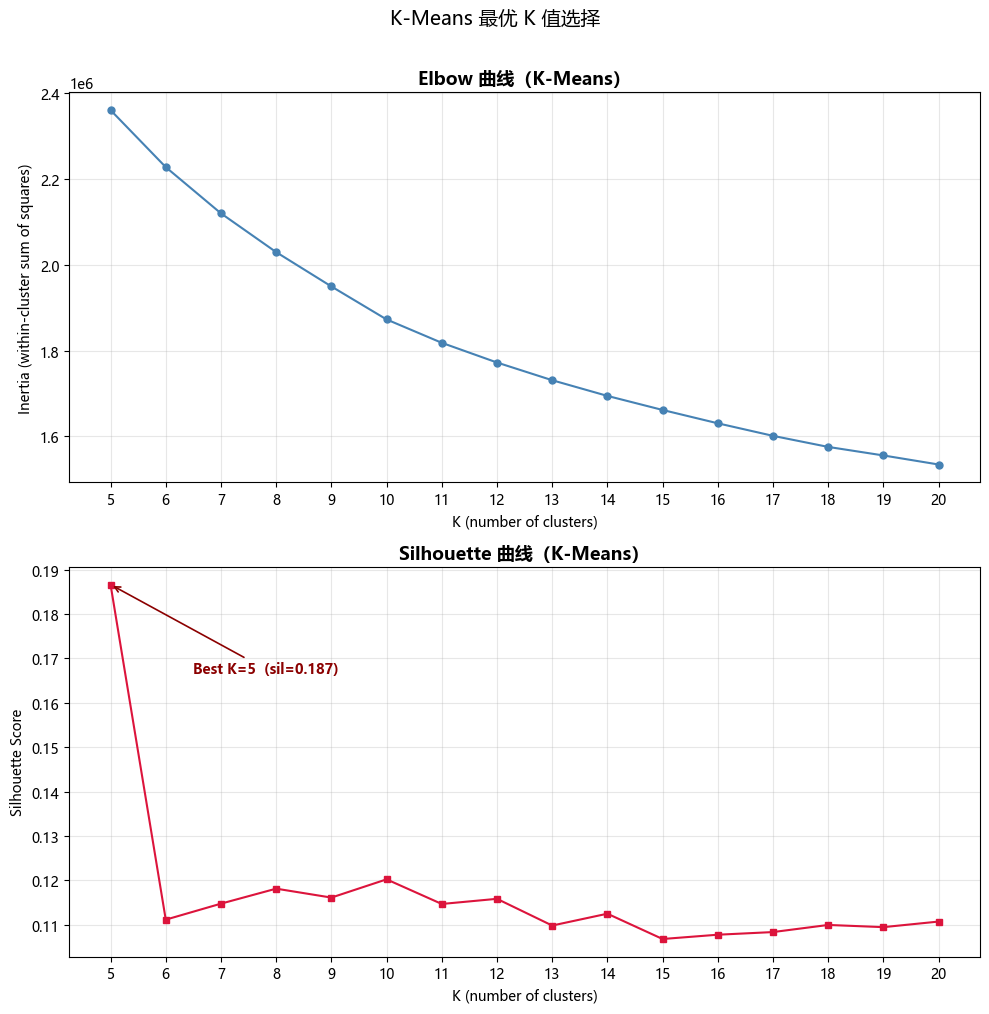


根据 Silhouette 曲线，推荐 K = 5（silhouette = 0.1866）
Elbow 曲线拐点附近的 K 值也可作为参考。


In [29]:
# ═══════════════════════════════════════════════════════════
#  绘图：Elbow（上）+ Silhouette（下）
# ═══════════════════════════════════════════════════════════

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# ── 上子图：Elbow 曲线 ──
ax1.plot(k_values, inertia_list, marker='o', linestyle='-', linewidth=1.5, markersize=5, color='steelblue')
ax1.set_title('Elbow 曲线（K-Means）', fontsize=13, fontweight='bold')
ax1.set_xlabel('K (number of clusters)')
ax1.set_ylabel('Inertia (within-cluster sum of squares)')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(list(k_values))

# ── 下子图：Silhouette 曲线 ──
ax2.plot(k_values, sil_list, marker='s', linestyle='-', linewidth=1.5, markersize=5, color='crimson')
ax2.set_title('Silhouette 曲线（K-Means）', fontsize=13, fontweight='bold')
ax2.set_xlabel('K (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(list(k_values))

# ── 标注 Silhouette 最高的 K ──
best_k_idx = np.argmax(sil_list)
best_k = k_values[best_k_idx]
best_sil = sil_list[best_k_idx]
ax2.annotate(f'Best K={best_k}  (sil={best_sil:.3f})',
             xy=(best_k, best_sil),
             xytext=(best_k + 1.5, best_sil - 0.02),
             arrowprops=dict(arrowstyle='->', color='darkred', lw=1.2),
             fontsize=10, color='darkred', fontweight='bold')

plt.suptitle('K-Means 最优 K 值选择', fontsize=14, y=1.01)
plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/kmeans_selection.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n根据 Silhouette 曲线，推荐 K = {best_k}（silhouette = {best_sil:.4f}）")
print(f"Elbow 曲线拐点附近的 K 值也可作为参考。")

## 4.2 选定 K 值 — 最终 K-Means + Cluster 画像

In [14]:
# ═══════════════════════════════════════════════════════════
#  选定最终 K 值并运行 K-Means
# ═══════════════════════════════════════════════════════════

# ── 根据上方曲线，手动填入最终 K 值 ──
# SELECTED_K = best_k   # Silhouette 推荐的 K，手动覆盖如下：
SELECTED_K = 10      # 如果需要固定值，取消注释此行并覆盖

print(f"最终参数: K={SELECTED_K}")
print("正在运行 K-Means...")

km_final = KMeans(n_clusters=SELECTED_K, n_init=10, random_state=42)
KM_labels = km_final.fit_predict(X_scaled)

n_total = len(KM_labels)

print(f"\n聚类完成:")
print(f"  总 block 数:   {n_total:,}")
print(f"  K:              {SELECTED_K}")
print(f"  Inertia:        {km_final.inertia_:.0f}")

# ── 模块级变量 ──
KM_LABELS  = KM_labels
KM_K       = SELECTED_K

最终参数: K=10
正在运行 K-Means...

聚类完成:
  总 block 数:   181,858
  K:              10
  Inertia:        1872345


In [15]:
# ═══════════════════════════════════════════════════════════
#  各 Cluster 的 Block 数量与占比
# ═══════════════════════════════════════════════════════════

unique_labels = sorted(set(KM_labels))

print(f"{'Cluster':>8}  {'Block数':>10}  {'占比':>8}  {'累计占比':>8}")
print("-" * 40)

cum_pct = 0.0
for label in unique_labels:
    count = (KM_labels == label).sum()
    pct   = count / n_total * 100
    cum_pct += pct
    print(f"  {int(label):>6d}  {count:>10,d}  {pct:>7.2f}%  {cum_pct:>7.2f}%")

print(f"\n总计: {n_total:,} blocks")

 Cluster      Block数        占比      累计占比
----------------------------------------
       0      20,993    11.54%    11.54%
       1      38,313    21.07%    32.61%
       2      31,134    17.12%    49.73%
       3      27,294    15.01%    64.74%
       4      18,840    10.36%    75.10%
       5       5,554     3.05%    78.15%
       6      14,445     7.94%    86.10%
       7       6,261     3.44%    89.54%
       8       5,678     3.12%    92.66%
       9      13,346     7.34%   100.00%

总计: 181,858 blocks


In [16]:
# ═══════════════════════════════════════════════════════════
#  Cluster 画像：19 个指标的均值 + 保存 CSV
# ═══════════════════════════════════════════════════════════

# 创建一个临时 DataFrame 用于分组计算
df_km = df_clean[CLUSTER_COLS].copy()
# df_km.columns = CLUSTER_COLS
df_km['cluster'] = KM_labels

cluster_means = df_km.groupby('cluster')[CLUSTER_COLS].mean()
cluster_counts = df_km.groupby('cluster').size()
cluster_means.insert(0, 'n_blocks', cluster_counts)

print("各 Cluster 的 19 个指标均值（用于形态解读）：")
print(f"\n{'Cluster':>8}  {'n_blocks':>10}", end='')
for col in CLUSTER_COLS:
    print(f"  {col:>18}", end='')
print()
print("-" * (10 + 12 + 20 * len(CLUSTER_COLS)))

for label in sorted(cluster_means.index):
    row = cluster_means.loc[label]
    print(f"  {int(label):>6d}  {int(row['n_blocks']):>10,d}", end='')
    for col in CLUSTER_COLS:
        print(f"  {row[col]:>16.4f}", end='')
    print()

# ── 保存 CSV ──
cluster_means.to_csv('output/kmeans_cluster_profile.csv', float_format='%.4f')
print(f"\n已保存: output/kmeans_cluster_profile.csv")

各 Cluster 的 19 个指标均值（用于形态解读）：

 Cluster    n_blocks             area_m2          elongation         compactness           convexity      rectangularity  lod1_building_count                 bcr                 far     avg_nn_distance                 avh                 hcv        total_volume       avg_footprint        footprint_cv      avg_complexity  avg_rectangularity       avg_convexity     avg_orientation  orientation_entropy
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
       0      20,993         9620.2854            3.7509            0.5662            0.9876            0.8884           29.2624            0.3121            0.780

# 5. 聚类结果可视化

## 5.1 UMAP 降维 + K-Means 聚类结果散点图

UMAP 降维（K-Means 结果）
原始数据: 181858 点 × 19 维

采样 50,000 点（共 181,858），共 10 个 cluster
  Cluster 0: 5,772 (11.5%)
  Cluster 1: 10,534 (21.1%)
  Cluster 2: 8,560 (17.1%)
  Cluster 3: 7,504 (15.0%)
  Cluster 4: 5,180 (10.4%)
  Cluster 5: 1,527 (3.1%)
  Cluster 6: 3,972 (7.9%)
  Cluster 7: 1,721 (3.4%)
  Cluster 8: 1,561 (3.1%)
  Cluster 9: 3,669 (7.3%)

运行 UMAP 降维（n_neighbors=30, min_dist=0.1）...
UMAP 降维完成: (50000, 2)

已保存: output/05_umap_kmeans_k10.png


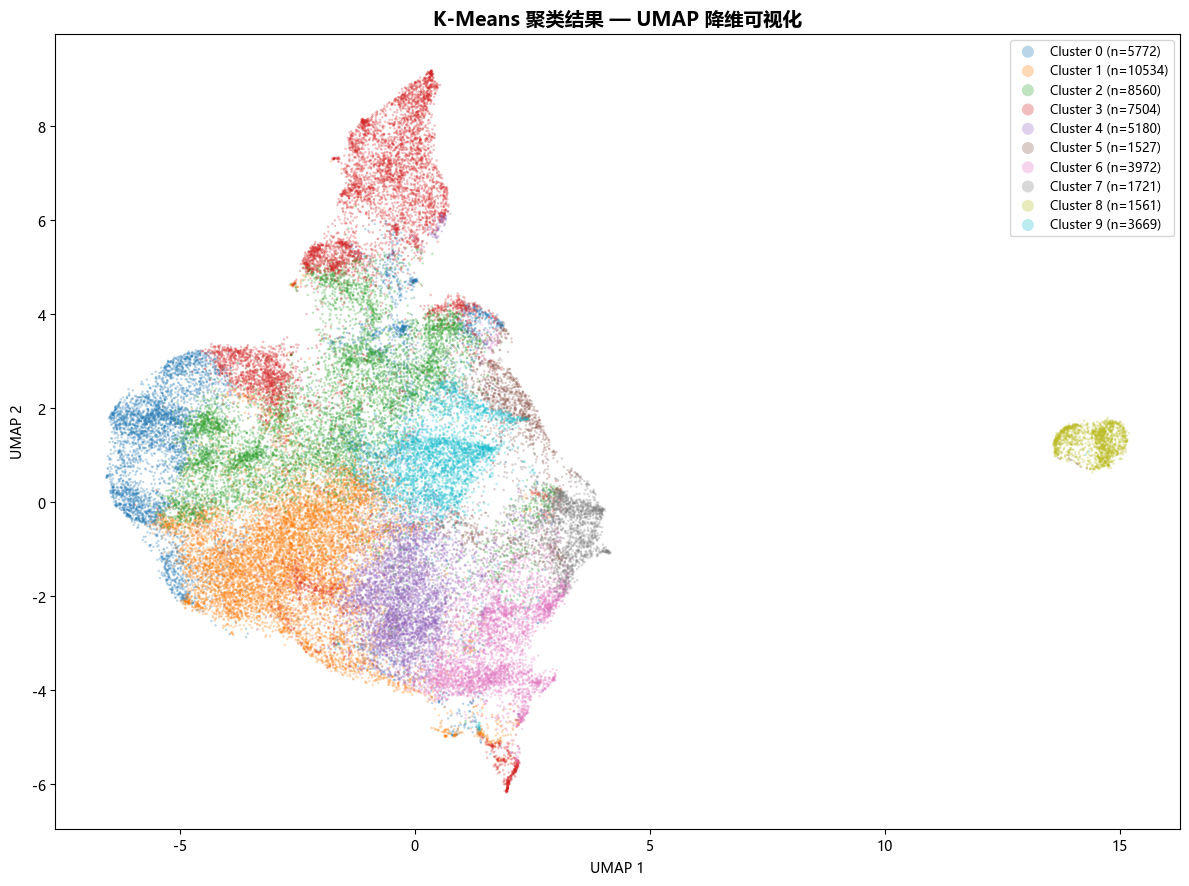

In [17]:
# ═══════════════════════════════════════════════════════════
#  依赖：Section 4.2 的 KM_LABELS（模块级变量）
#  用 stratified sampling 保持 cluster 比例，采样30,000点
#  输出：output/05_umap_kmeans.png
# ═══════════════════════════════════════════════════════════

from umap import UMAP
from sklearn.model_selection import train_test_split

# ── 检查 KM_LABELS 是否存在 ──
try:
    _ = KM_LABELS
except NameError:
    raise NameError("KM_LABELS 未定义。请先运行 Section 4.2 的 K-Means 聚类代码。")

print("=" * 60)
print("UMAP 降维（K-Means 结果）")
print(f"原始数据: {X_scaled.shape[0]} 点 × {X_scaled.shape[1]} 维")
print("=" * 60)

# ── 1. Stratified Sampling（保持 cluster 比例）──
SAMPLE_SIZE = 50_000

X_sample, _, labels_sample, _ = train_test_split(
    X_scaled, KM_LABELS,
    train_size=SAMPLE_SIZE,
    stratify=KM_LABELS,
    random_state=42
)

unique_labels  = sorted(set(labels_sample))
n_clusters_found = len(unique_labels)

cluster_counts = pd.Series(labels_sample).value_counts().sort_index()
print(f"\n采样 {SAMPLE_SIZE:,} 点（共 {len(X_scaled):,}），共 {n_clusters_found} 个 cluster")
for lbl in unique_labels:
    cnt = cluster_counts[lbl]
    pct = cnt / SAMPLE_SIZE * 100
    print(f"  Cluster {lbl}: {cnt:,} ({pct:.1f}%)")

# ── 2. UMAP 降维 ──
print("\n运行 UMAP 降维（n_neighbors=30, min_dist=0.1）...")
reducer = UMAP(n_neighbors=30, min_dist=0.1, metric='euclidean', random_state=42)
X_umap = reducer.fit_transform(X_sample)
print(f"UMAP 降维完成: {X_umap.shape}")

# ── 3. 绘图 ──
fig, ax = plt.subplots(figsize=(12, 10))

# 颜色映射
cmap = plt.cm.tab10  # 最多10种颜色，足够覆盖常见K
colors = [cmap(i % 10) for i in range(n_clusters_found)]

for idx, lbl in enumerate(unique_labels):
    mask = labels_sample == lbl
    cnt = mask.sum()
    ax.scatter(
        X_umap[mask, 0], X_umap[mask, 1],
        c=[colors[idx]],
        label=f'Cluster {lbl} (n={cnt})',
        alpha=0.3, s=3, edgecolors='none'
    )

ax.set_title('K-Means 聚类结果 — UMAP 降维可视化', fontsize=14, fontweight='bold')
ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.legend(markerscale=5, fontsize=9, loc='best')
ax.grid(False)
ax.set_aspect('equal')

plt.tight_layout()
os.makedirs('output', exist_ok=True)
plt.savefig('output/05_umap_kmeans_k10.png', dpi=300, bbox_inches='tight')
# plt.show()

print(f"\n已保存: output/05_umap_kmeans_k10.png")

## 5.2 各 Cluster 典型 Block 可视化

对每个 cluster，取最靠近质心的 5 个 block，绘制 2D 平面拼图和 3D 轴测拼图。

In [18]:
# ═══════════════════════════════════════════════════════════
#  取每个 cluster 最靠近质心的 5 个 block
# ═══════════════════════════════════════════════════════════

from scipy.spatial.distance import cdist

N_PER_CLUSTER = 5
unique_clusters = sorted(set(KM_LABELS))
n_clusters = len(unique_clusters)

centroids = km_final.cluster_centers_

selected_blocks = []  # [(cluster, block_id, city_display, distance), ...]

for lbl in unique_clusters:
    mask = KM_LABELS == lbl
    X_cluster = X_scaled[mask]
    idx_cluster = np.where(mask)[0]
    centroid = centroids[lbl].reshape(1, -1)
    
    dists = cdist(X_cluster, centroid, metric='euclidean').flatten()
    nearest_idx = np.argsort(dists)[:N_PER_CLUSTER]
    
    for ni in nearest_idx:
        global_idx = idx_cluster[ni]
        bid = block_ids.iloc[global_idx]
        city_display = df_clean['_city'].iloc[global_idx]
        selected_blocks.append((int(lbl), bid, city_display, dists[ni]))

df_selected = pd.DataFrame(selected_blocks,
    columns=['cluster', 'block_id', 'city', 'distance'])

print(f"从 {n_clusters} 个 cluster 中各选 {N_PER_CLUSTER} 个典型 block（共 {len(df_selected)} 个）\n")
display(df_selected)

从 10 个 cluster 中各选 5 个典型 block（共 50 个）



,cluster,block_id,city,distance
0,0,JP_KA_003496,Kanazawa,0.889618
1,0,JP_KA_004286,Kanazawa,0.896259
2,0,JP_SP_019732,Sapporo,0.897408
3,0,JP_SP_013591,Sapporo,0.930095
4,0,JP_SP_021374,Sapporo,0.964802
5,1,JP_TK_070950,Tokyo,0.801155
6,1,JP_TK_073213,Tokyo,0.918269
7,1,JP_TK_071874,Tokyo,0.919654
8,1,JP_TK_073131,Tokyo,0.939965
9,1,JP_TK_044827,Tokyo,0.945507


In [19]:
# ═══════════════════════════════════════════════════════════
#  从数据库查询 block geom + 建筑 footprint + surfaces
# ═══════════════════════════════════════════════════════════

# ── 按城市分组查询 ──
city_groups = df_selected.groupby('city')

block_geom_data  = {}   # block_id -> {'geom_wkt': ..., 'footprints': [wkt, ...]}
surface_data     = {}   # block_id -> [(surface_type, geom_3d_wkt), ...]

for city_display, group in city_groups:
    city_query = utils_z.run_sql(
        "SELECT city_query FROM block.city_name_map WHERE city = %s;",
        params=(city_display,), fetch=True, conn=conn
    )[0][0]
    block_ids_list = group['block_id'].tolist()
    placeholders = ", ".join([f"'{bid}'" for bid in block_ids_list])
    
    block_table = f"block.{city_query}_blocks"
    bld_table = f"lod1.{city_query}_buildings_lod1"
    surf_table = f"lod1.{city_query}_building_surfaces_lod1"
    
    # ── 查询 block geom ──
    rows_block = utils_z.run_sql(f"""
        SELECT block_id, ST_AsText(geom) FROM {block_table}
        WHERE block_id IN ({placeholders});
    """, fetch=True, conn=conn)
    for bid, wkt in rows_block:
        block_geom_data[str(bid)] = {'geom_wkt': wkt, 'footprints': []}
    
    # ── 查询 building footprints (geom_2d) ──
    rows_fp = utils_z.run_sql(f"""
        SELECT block_id, ST_AsText(geom_2d)
        FROM {bld_table}
        WHERE block_id IN ({placeholders})
          AND geom_2d IS NOT NULL AND ST_IsValid(geom_2d);
    """, fetch=True, conn=conn)
    for bid, wkt in rows_fp:
        if str(bid) in block_geom_data:
            block_geom_data[str(bid)]['footprints'].append(wkt)
    
    # ── 查询 building surfaces（用于 3D）──
    rows_surf = utils_z.run_sql(f"""
        SELECT b.block_id, s.surface_type, ST_AsText(s.geom_3d)
        FROM {surf_table} s
        JOIN {bld_table} b ON s.building_id = b.building_id
        WHERE b.block_id IN ({placeholders});
    """, fetch=True, conn=conn)
    for bid, stype, wkt in rows_surf:
        key = str(bid)
        if key not in surface_data:
            surface_data[key] = []
        surface_data[key].append((stype, wkt))

print(f"查询完成: {len(block_geom_data)} blocks, {sum(len(v['footprints']) for v in block_geom_data.values())} footprints")

查询完成: 50 blocks, 1710 footprints


In [ ]:
# ═══════════════════════════════════════════════════════════
#  2D 拼图：block 边界 + 建筑 footprint
# ═══════════════════════════════════════════════════════════

import math
from shapely.wkt import loads as wkt_loads

n_rows = n_clusters
n_cols = N_PER_CLUSTER

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3))
fig.suptitle('各 Cluster 典型 Block — 2D 平面图（Block + Building Footprint）',
             fontsize=14, y=1.01)

DISPLAY_RANGE = 1.0   # 所有子图统一显示在 [-1, 1] × [-1, 1] 的归一化空间
PADDING       = 0.1  # 留边比例（相对于归一化空间）

for idx, row in df_selected.iterrows():
    lbl  = row['cluster']
    bid  = row['block_id']
    city = row['city']

    r_idx = int(lbl)
    c_idx = list(df_selected[df_selected['cluster'] == lbl].index).index(idx)

    if n_rows > 1:
        ax = axes[r_idx, c_idx]
    else:
        ax = axes[c_idx] if n_cols > 1 else axes

    # ── 解析 block geom ──
    geom_entry = block_geom_data.get(bid)
    if geom_entry is None or wkt_loads(geom_entry['geom_wkt']).is_empty:
        ax.text(0.02, 0.98, f'C{lbl} | {bid} | {city}（无数据）', fontsize=7,
                transform=ax.transAxes, va='top', ha='left')
        ax.set_xticks([])
        ax.set_yticks([])
        continue

    block_poly = wkt_loads(geom_entry['geom_wkt'])

    # ── 局部投影：地理坐标 → 米制坐标 ──
    minx, miny, maxx, maxy = block_poly.bounds
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2
    meters_per_deg_lat = 111320
    meters_per_deg_lon = math.cos(math.radians(cy)) * 111320

    def to_local(coords_x, coords_y):
        return (
            [(x - cx) * meters_per_deg_lon for x in coords_x],
            [(y - cy) * meters_per_deg_lat for y in coords_y],
        )

    # ── 计算 block 在米制空间的最大跨度，用于归一化 ──
    bx_raw, by_raw = block_poly.exterior.xy
    bx_local, by_local = to_local(bx_raw, by_raw)
    half_span = max(
        max(bx_local) - min(bx_local),
        max(by_local) - min(by_local),
    ) / 2 or 1.0   # 防止除零

    def normalize(vals):
        """将米制坐标压缩到 [-1, 1] 归一化空间"""
        return [v / half_span for v in vals]

    # ── 绘制 block 边界 ──
    ax.plot(normalize(bx_local), normalize(by_local),
            color='#333333', linewidth=1.5, zorder=2)

    # ── 绘制建筑 footprint ──
    for fp_wkt in geom_entry['footprints']:
        try:
            fp_poly = wkt_loads(fp_wkt)
            if fp_poly.is_empty:
                continue
            fx, fy = fp_poly.exterior.xy
            fx_local, fy_local = to_local(fx, fy)
            ax.fill(normalize(fx_local), normalize(fy_local),
                    color='#4A72B5', alpha=0.5, edgecolor='#2C3E6B',
                    linewidth=0.5, zorder=3)
        except Exception:
            pass

    # ── 统一坐标轴范围（所有子图完全一致）──
    lim = DISPLAY_RANGE + PADDING
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    # 不再使用 set_aspect('equal')，由统一的 xlim/ylim + figsize 保证方形外观

    ax.text(0.02, 0.98, f'C{lbl} | {bid} | {city}', fontsize=7,
            transform=ax.transAxes, va='top', ha='left')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_color('#cccccc')

plt.tight_layout()
plt.savefig('output/06_blocks_2d_k10.png', dpi=300, bbox_inches='tight')
plt.close()
print("已保存: output/06_blocks_2d_k10.png")

已保存: output/06_blocks_2d_k10.png


In [ ]:
# ═══════════════════════════════════════════════════════════
#  3D 轴测拼图：立体 block + 建筑（pyvista off-screen）
# ═══════════════════════════════════════════════════════════
import pyvista as pv
import math

# ── 辅助函数：polygon → triangulated mesh（复用 block_unit_viz_lod1.py 逻辑）──
def polygon_to_mesh(coords, cx, cy, base_z,
                    meters_per_deg_lon, meters_per_deg_lat, z_scale=1.0):
    pts = np.array([
        [(c[0] - cx) * meters_per_deg_lon,
         (c[1] - cy) * meters_per_deg_lat,
         ((c[2] if len(c) > 2 else base_z) - base_z) * z_scale]
        for c in coords[:-1]
    ])
    if len(pts) < 3:
        return None
    faces = np.array([len(pts)] + list(range(len(pts))))
    return pv.PolyData(pts, faces).triangulate()


def build_block_mesh_3d(bid, geom_entry, surfaces):
    """返回 (block_mesh, building_mesh) 供 pyvista 渲染"""
    block_poly = wkt_loads(geom_entry['geom_wkt'])
    if block_poly.is_empty:
        return None, None

    minx, miny, maxx, maxy = block_poly.bounds
    cx = (minx + maxx) / 2
    cy = (miny + maxy) / 2

    meters_per_deg_lat = 111320
    meters_per_deg_lon = math.cos(math.radians(cy)) * 111320

    base_z = float('inf')
    for stype, wkt in surfaces:
        try:
            poly = wkt_loads(wkt)
            for c in poly.exterior.coords:
                if len(c) > 2:
                    base_z = min(base_z, c[2])
        except Exception:
            pass
    if base_z == float('inf'):
        base_z = 0.0

    # block mesh
    block_mesh = None
    try:
        coords = list(block_poly.exterior.coords)
        block_mesh = polygon_to_mesh(coords, cx, cy, base_z,
                                    meters_per_deg_lon, meters_per_deg_lat)
    except Exception:
        pass

    # building surfaces
    meshes = []
    for stype, wkt in surfaces:
        try:
            poly = wkt_loads(wkt)
            coords = list(poly.exterior.coords)
            if len(coords) < 4:
                continue
            mesh = polygon_to_mesh(coords, cx, cy, base_z,
                                  meters_per_deg_lon, meters_per_deg_lat, 1.0)
            if mesh is None or mesh.n_points == 0 or mesh.n_cells == 0:
                continue
            if stype == "RoofSurface":
                color = (241, 164, 147)  # #f1a493
            elif stype == "WallSurface":
                color = (248, 239, 234)  # #f8efea
            else:
                color = (193, 164, 160)  # #c1a4a0
            mesh['color'] = np.tile(color, (mesh.n_cells, 1))
            meshes.append(mesh)
        except Exception:
            pass

    building_mesh = None
    if meshes:
        building_mesh = meshes[0].merge(meshes[1:]) if len(meshes) > 1 else meshes[0]

    return block_mesh, building_mesh


# ── 创建 off-screen plotter ──
plotter = pv.Plotter(shape=(n_rows, n_cols), window_size=[3000, 2500], off_screen=True)
plotter.set_background('#FFFFFF')

for idx, row in df_selected.iterrows():
    lbl  = row['cluster']
    bid  = row['block_id']
    
    r_idx = int(lbl)
    c_idx = list(df_selected[df_selected['cluster'] == lbl].index).index(idx)
    
    plotter.subplot(r_idx, c_idx)

    geom_entry = block_geom_data.get(bid)
    surf_list  = surface_data.get(bid, [])
    if geom_entry is None:
        continue

    block_mesh, building_mesh = build_block_mesh_3d(bid, geom_entry, surf_list)

    if building_mesh is not None:
        plotter.add_mesh(building_mesh, scalars='color', rgb=True, show_edges=False)
        edges = building_mesh.extract_feature_edges(
            boundary_edges=True, feature_edges=True, feature_angle=30, manifold_edges=False)
        plotter.add_mesh(edges, color='#383838', line_width=0.8)

    if block_mesh is not None:
        plotter.add_mesh(block_mesh, color='#e0d0c8', opacity=0.3, show_edges=False)
        block_edges = block_mesh.extract_feature_edges(
            boundary_edges=True, feature_edges=False, manifold_edges=False)
        plotter.add_mesh(block_edges, color='#1F1F1F', line_width=2)

    plotter.add_text(f'C{lbl} | {bid}', font_size=8, position='upper_left')
    plotter.camera_position = 'iso'
    plotter.camera.zoom(1.5)

plotter.screenshot('output/06_blocks_3d_k10.png')
print(f"已保存: output/06_blocks_3d.png")

已保存: output/06_blocks_3d.png


# 临时处理

In [37]:
CITY_NAME_MAP = {
    "Hamburg": "hamburg",
    "San Francisco": "sanfrancisco",
    "Amsterdam": "amsterdam",
    "Dresden": "dresden",
    "Berlin": "berlin",
    "Rotterdam": "rotterdam",
    "Luxembourg": "luxembourg",
    "Chicago": "chicago",
    "Boston": "boston",
    "Washington D.C.": "washington",
    "New York": "newyork",
    "Portland": "portland",
    "Tokyo": "tokyo",
    "Sapporo": "sapporo",
    "Osaka": "osaka",
    "Kanazawa": "kanazawa",
    "Toronto": "toronto",
    "Vienna": "vienna",
    "Winnipeg": "winnipeg",
    "Zurich": "zurich",
    "Bologna": "bologna",
    "Paris": "paris",
    "Lyon": "lyon",
    "Marseille": "marseille",
    "Montreal": "montreal",
    "Hannover": "hannover",
    "Linz": "linz",
    "Namur": "namur",
    "Prague": "prague",
    "Tallinn": "tallinn",
    "Munich": "munich",
    "Nuremberg": "nuremberg",
    "Bern": "bern",
}

In [40]:
# ═══════════════════════════════════════════════════════════
#  建 block.city_name_map 表 + 写入数据
#  首次运行执行一次即可，后续可跳过
# ═══════════════════════════════════════════════════════════

utils_z.run_sql("""
    CREATE TABLE IF NOT EXISTS block.city_name_map (
        city        VARCHAR PRIMARY KEY,
        city_query  VARCHAR NOT NULL
    );
""", conn=conn)

# ── 检查是否已有数据 ──
existing = utils_z.run_sql(
    "SELECT COUNT(*) FROM block.city_name_map;", fetch=True, conn=conn
)[0][0]

if existing == 0:
    values = [(city, q) for city, q in CITY_NAME_MAP.items()]
    with conn.cursor() as cur:
        from psycopg2.extras import execute_values
        execute_values(cur,
            "INSERT INTO block.city_name_map (city, city_query) VALUES %s;",
            values
        )
    conn.commit()
    print(f"已插入 {len(values)} 条城市映射记录")
else:
    print(f"表已有 {existing} 条记录，跳过插入")

已插入 33 条城市映射记录
